#### 0. Load Prereqs + Initial Preprocessing

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from typing import cast

from transformers import AutoTokenizer, PreTrainedTokenizerBase, DataCollatorWithPadding

In [3]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()
login(os.getenv("HF_READ_TOKEN"))

In [4]:
df = pd.read_csv("../assets/IMDB_Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
X = df['review']
y = df['sentiment'].map({'negative': 0, 'positive': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.3, random_state= 1000
)

train_ds = Dataset.from_dict({
    "text": list(X_train),
    "label": list(y_train)
})

test_ds  = Dataset.from_dict({
    "text": list(X_test),
    "label": list(y_test)
})

dataset = DatasetDict({"train": train_ds, "test": test_ds})

In [6]:
MAX_LEN = 512

model_name = "distilbert-base-uncased"
tokenizer = cast(
    PreTrainedTokenizerBase,
    cast(object, AutoTokenizer.from_pretrained(model_name))
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="longest")

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False
    )

In [7]:
tokenized_ds = dataset.map(tokenize_batch, batched=True, remove_columns=["text"])
tokenized_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map: 100%|██████████| 15000/15000 [00:03<00:00, 3870.49 examples/s]


In [8]:
# helper functions

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from scipy.special import softmax

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs_pos = softmax(logits, axis=1)[:,1]
    preds = np.argmax(logits, axis=1)

    auc = roc_auc_score(labels, probs_pos)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)

    return {"accuracy": acc, "f1": f1, "auc": auc}

## 1. DistilBERT-base-uncased model training on IMDB sentiment classification

In [10]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

#### 1.1 Full Fine-Tuning

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 398.50it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
training_args = TrainingArguments(
    output_dir="D:/models/imdb-distillbert",
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="auc",
    greater_is_better=True,
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,0.117612,0.320101,0.930067,0.929203,0.979215
2,0.101148,0.367086,0.930000,0.929083,0.980246
3,0.040345,0.408756,0.933600,0.933653,0.979618


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.74it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=13125, training_loss=0.10040639303298224, metrics={'train_runtime': 2645.834, 'train_samples_per_second': 39.685, 'train_steps_per_second': 4.961, 'total_flos': 1.3074882044071776e+16, 'train_loss': 0.10040639303298224, 'epoch': 3.0})

In [19]:
results = trainer.evaluate()
print(f"Evaluation Results: {results}")

Evaluation Results: {'eval_loss': 0.36702531576156616, 'eval_accuracy': 0.9299333333333333, 'eval_f1': 0.9290104694360013, 'eval_auc': 0.980248027577006, 'eval_runtime': 60.603, 'eval_samples_per_second': 247.512, 'eval_steps_per_second': 30.939, 'epoch': 3.0}


In [22]:
trainer.save_model("D:/models/imdb-distilbert-final")
tokenizer.save_pretrained("D:/models/imdb-distilbert-final")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.92it/s]


('D:/ml_models/imdb-distilbert-final\\tokenizer_config.json',
 'D:/ml_models/imdb-distilbert-final\\tokenizer.json')

#### 1.2 Parameter-Efficient Fine-Tuning with LoRA (Low-Rank Adapation)

In [27]:
from peft import LoraConfig, get_peft_model, TaskType

In [10]:
base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.1,
    bias="none",
)

peft_model = get_peft_model(base_model, lora_config)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 339.38it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
peft_model.print_trainable_parameters()

trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


In [12]:
training_args = TrainingArguments(
    output_dir="D:/models/imdb-distillbert-lora",
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="auc",
    greater_is_better=True,
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [13]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,0.269684,0.275633,0.895133,0.896493,0.962295
2,0.257383,0.266697,0.903333,0.902501,0.966132
3,0.246624,0.265435,0.904667,0.904832,0.967151


TrainOutput(global_step=13125, training_loss=0.2803733819870722, metrics={'train_runtime': 2051.5301, 'train_samples_per_second': 51.181, 'train_steps_per_second': 6.398, 'total_flos': 1.3299135252143808e+16, 'train_loss': 0.2803733819870722, 'epoch': 3.0})

In [14]:
trainer.evaluate()

{'eval_loss': 0.2654346823692322,
 'eval_accuracy': 0.9046666666666666,
 'eval_f1': 0.9048316251830161,
 'eval_auc': 0.9671508821834076,
 'eval_runtime': 99.7496,
 'eval_samples_per_second': 150.377,
 'eval_steps_per_second': 18.797,
 'epoch': 3.0}

In [16]:
print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Allocated: 0.29 GB


In [15]:
trainer.save_model("D:/models/imdb-distilbert-lora-final")
tokenizer.save_pretrained("D:/models/imdb-distilbert-lora-final")

('D:/models/imdb-distilbert-lora-final\\tokenizer_config.json',
 'D:/models/imdb-distilbert-lora-final\\tokenizer.json')

#### 1.3 LoRA hyper-tuned: `r` (rank), `lora_alpha`, and `target_modules`

In [33]:
base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    target_modules=["q_lin", "k_lin", "v_lin", "out_lin"],
    lora_dropout=0.1,
    bias="none",
)

peft_model = get_peft_model(base_model, lora_config)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 628.75it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [34]:
training_args = TrainingArguments(
    output_dir="D:/models/imdb-distillbert-lora-2",
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="auc",
    greater_is_better=True,
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [35]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,0.258444,0.259736,0.905867,0.905564,0.967086
2,0.241319,0.257739,0.909933,0.909699,0.970353
3,0.221808,0.258181,0.912067,0.912073,0.971343


TrainOutput(global_step=13125, training_loss=0.26411739618210567, metrics={'train_runtime': 2115.2798, 'train_samples_per_second': 49.639, 'train_steps_per_second': 6.205, 'total_flos': 1.3433267649388224e+16, 'train_loss': 0.26411739618210567, 'epoch': 3.0})

In [36]:
trainer.save_model("D:/models/imdb-distilbert-lora-final-2")
tokenizer.save_pretrained("D:/models/imdb-distilbert-lora-final-2")

('D:/models/imdb-distilbert-lora-final-2\\tokenizer_config.json',
 'D:/models/imdb-distilbert-lora-final-2\\tokenizer.json')

#### 1.4 LoRA with scaled up/higher-parameter model: `roberta-base`

## 2. Geometry Analysis

#### 2.0 Helper Functions

In [20]:
from tqdm import tqdm # progress bar
from transformers import AutoModelForSequenceClassification
from peft import PeftModel

In [12]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [13]:
def pool_embeddings(hidden_states, attention_mask, pooling):
    """
    :param hidden_states: torch.Tensor (batch, seq_len, hidden_dim) from a chosen layer
    :param attention_mask: torch.Tensor (batch, seq_len)
    :param pooling: 'cls' (classification head) | 'mean' | 'max'
    :return: (batch, hidden_dim)
    """

    if pooling == "cls":
        return (hidden_states[:, 0, :]
            .detach()
            .cpu()
            .numpy())
    elif pooling == "mean":
        mask = attention_mask.unsqueeze(-1).type(hidden_states.dtype)
        summed = (hidden_states * mask).sum(dim=1)
        denom = mask.sum(dim=1).clamp(min=1e-9)
        return (summed / denom).detach().cpu().numpy()
    elif pooling == "max":
        mask = attention_mask.unsqueeze(-1).bool()
        decreased = hidden_states.masked_fill(~mask, -1e9)
        return decreased.max(dim=1).values.detach().cpu().numpy()
    else:
        raise ValueError("Unknown pooling: {}".format(pooling))

In [24]:
def extract_doc_embeddings(model, dataset, batch_size=32, layer=-1, pooling="cls", save_path=None):
    """
    :param model: HF model with output_hidden_states=True
    :param dataset: tokenized_dataset split
    :param layer: integer or negative index of layer to use from hidden_states
    :param pooling: 'cls' (classification head) | 'mean' | 'max'
    :return: numpy array (n_examples, hidden_dim)
    """

    from torch.utils.data import DataLoader

    dl = DataLoader(dataset, batch_size=batch_size, collate_fn=data_collator)

    all_embs = []
    with torch.no_grad():
        for batch in tqdm(dl, desc="extract"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            out = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
            )
            hidden_states = out.hidden_states[layer]
            embs = pool_embeddings(hidden_states, attention_mask, pooling=pooling)
            all_embs.append(embs)

    embs_np = np.vstack(all_embs)
    if save_path:
        np.save(save_path, embs_np)
    return embs_np

In [15]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import silhouette_score
# from sklearn.preprocessing import StandardScaler, normalize
import matplotlib.pyplot as plt
import numpy as np

In [16]:
def centroid_stats(X, y):
    pos = X[y==1]
    neg = X[y==0]
    cpos = pos.mean(axis=0); cneg = neg.mean(axis=0)
    inter = np.linalg.norm(cpos - cneg)
    intra_pos = np.mean(np.linalg.norm(pos - cpos, axis=1))
    intra_neg = np.mean(np.linalg.norm(neg - cneg, axis=1))
    return inter, (intra_pos+intra_neg)/2, inter/((intra_pos+intra_neg)/2 + 1e-12)

def probe_logistic(X_train, X_test, y_train, y_test):
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    probs = clf.predict_proba(X_test)[:,1]
    return {
        "acc": accuracy_score(y_test, preds),
        "auc": roc_auc_score(y_test, probs)
    }

In [17]:
def pca_tsne_plot_and_metrics(X_train, X_test, y_train, y_test, label="CLS-last"):
    pca = PCA(n_components=50, random_state=42)
    X50 = pca.fit_transform(np.vstack([X_train, X_test]))
    X50_train = X50[:len(X_train)]; X50_test = X50[len(X_train):]
    print("PCA(50) explained variance sum:", pca.explained_variance_ratio_.sum())

    subset = np.random.choice(len(X50_train), size=min(3000, len(X50_train)), replace=False)

    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X50_train[subset])

    plt.figure(figsize=(6,5))
    plt.scatter(X_tsne[:,0], X_tsne[:,1],
            c=y_train.iloc[subset], cmap="coolwarm", s=6, alpha=0.6)
    plt.title(f"{label} PCA50 ->t-SNE (train subset)")
    plt.show()

    inter, mean_intra, ratio = centroid_stats(X_train, y_train.values)
    print("centroid inter:", inter, "mean intra:", mean_intra, "ratio:", ratio)
    res = probe_logistic(X_train, X_test, y_train, y_test)
    print("Logistic probe:", res)
    sil = silhouette_score(X50_train, y_train)
    print("silhouette score:", sil)

#### 2.1 Full Fine-Tuning

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    "D:/models/imdb-distilbert-final",
    output_hidden_states=True
)

model.to(device)
model.eval # turns off DropOut,... layer for inference/evaluation

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7055.29it/s]


<bound method PreTrainedModel.eval of DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dr

In [21]:
# print classification head

text = "test This movie was great!"
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
input_ids = inputs["input_ids"].to(device)
attention_mask = inputs["attention_mask"].to(device)

outputs = model(input_ids, attention_mask, output_hidden_states=True)
last_hidden = outputs.hidden_states[-1]
cls_emb = last_hidden[:, 0, :]
#print(cls_emb)
print(cls_emb.shape)

torch.Size([1, 768])


In [20]:
X_train_cls = extract_doc_embeddings(model, tokenized_ds["train"], batch_size=32, pooling="cls")
X_test_cls = extract_doc_embeddings(model, tokenized_ds["test"], batch_size=32, pooling="cls")

extract: 100%|██████████| 469/469 [09:12<00:00,  1.18s/it]


PCA(50) explained variance sum: 0.9740693


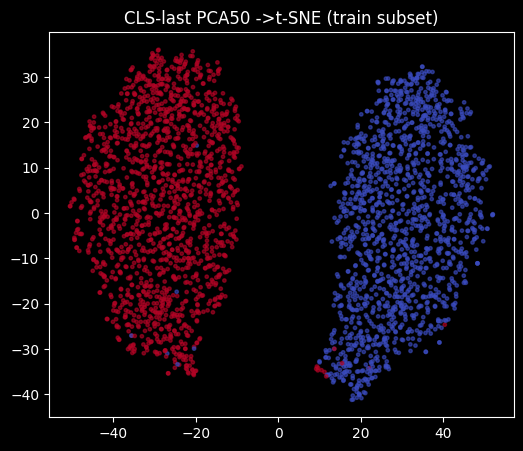

centroid inter: 28.151876 mean intra: 4.315059 ratio: 6.5241
Logistic probe: {'acc': 0.932, 'auc': 0.9697285508693938}
silhouette score: 0.8096044063568115


In [25]:
pca_tsne_plot_and_metrics(X_train_cls, X_test_cls, y_train, y_test, label="CLS-last")

**Notes**

* PCA retained about 97% of the variance in 50 components, suggesting that the CLS embeddings are highly compressible and that most of the task-relevant information lies in a relatively low-dimensional subspace
* The t-SNE visualization shows two well-seperated clusters for postive and negative reviews, indicating a strong class strcture in the learned embedding space
* The centroid distance between classes more than six times the average within-class spread, showing that inter-class speration is much larger than intra-class variation
* A silhouette score of about 0.81 indicates clusters aare compact and well-separated
* A logistic regression probe on the frozen CLS vectors achieves high accuracy and AUC, showing that sentiment is linearly accesible in the representation
* Overall, DistilBERT embeddings encode sentiment in a much more seperable and compact geometry than the earlier TF-IDF and GloVe representations



**Concepts**
* Attention mechanisms makes each token representation context-dependent, so word meaning changes based on surrounding words
* Positional embeddings preserve order, allowing the model to encode phrase structure and negation
* Stacked transformer layers build progressively richer features, moving from surface form toward task-relevant abstractions
* Pretraining gives the model broad language knowledge, and fine-tuning reshapes that knowledge for sentiment classification
* Fine-tuning makes the final layer easier to read with a linear classifier, which is why logistic regression performs so well on the CLS vectors

-- transformers rotate the space compared to naive models
<br>-- transfer learning from pretrained model



#### 2.1 Parameter Efficient Fine-Tuning

In [21]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    output_hidden_states=True
)

peft_model = PeftModel.from_pretrained(
    base_model,
    "D:/models/imdb-distilbert-lora-final"
)

peft_model.to(device)
peft_model.eval()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 304.71it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): DistilBertForSequenceClassification(
      (distilbert): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): DistilBertSelfAttention(
                (q_lin): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=8, bias=False)
                  )
      

In [25]:
X_train_cls = extract_doc_embeddings(peft_model, tokenized_ds["train"], batch_size=32, pooling="cls")
X_test_cls = extract_doc_embeddings(peft_model, tokenized_ds["test"], batch_size=32, pooling="cls")

extract: 100%|██████████| 469/469 [06:09<00:00,  1.27it/s]


PCA(50) explained variance sum: 0.85562944


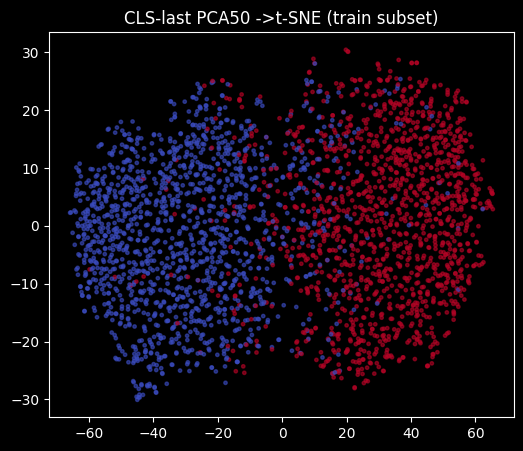

centroid inter: 9.289933 mean intra: 7.708508 ratio: 1.2051532
Logistic probe: {'acc': 0.9114666666666666, 'auc': 0.9708413080009232}
silhouette score: 0.2568720877170563


In [26]:
pca_tsne_plot_and_metrics(X_train_cls, X_test_cls, y_train, y_test, label="CLS-last")

#### 2.3 Hyper-tuned PEFT

In [37]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    output_hidden_states=True
)

peft_model = PeftModel.from_pretrained(
    base_model,
    "D:/models/imdb-distilbert-lora-final-2"
)

peft_model.to(device)
peft_model.eval()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 442.45it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): DistilBertForSequenceClassification(
      (distilbert): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): DistilBertSelfAttention(
                (q_lin): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=16, bias=False)
                  )
     

In [38]:
X_train_cls = extract_doc_embeddings(peft_model, tokenized_ds["train"], batch_size=32, pooling="cls")
X_test_cls = extract_doc_embeddings(peft_model, tokenized_ds["test"], batch_size=32, pooling="cls")

extract: 100%|██████████| 469/469 [07:51<00:00,  1.01s/it]


PCA(50) explained variance sum: 0.8734961


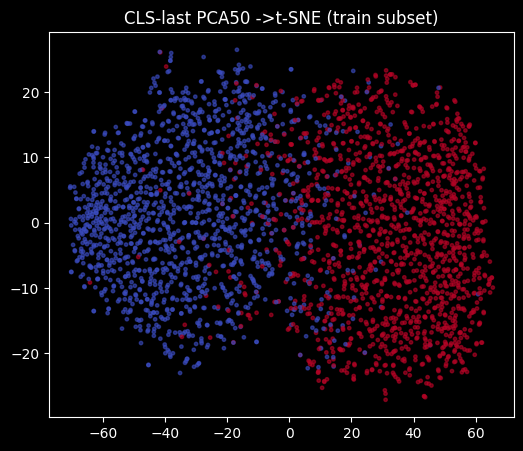

centroid inter: 12.017679 mean intra: 7.9309206 ratio: 1.5152943
Logistic probe: {'acc': 0.9157333333333333, 'auc': 0.9731154271655282}
silhouette score: 0.33702394366264343


In [39]:
pca_tsne_plot_and_metrics(X_train_cls, X_test_cls, y_train, y_test, label="CLS-last")

**Notes**
* The geometric differences suggest that full fine-tuning reshapes the embedding space more aggressively, producing representations that are more compact and more class-aligned under PCA and t-SNE. LoRA, by contrast, preserves more of the pretrained structure and therefore yields weaker visual separation, even though the class information remains strongly linearly decodable, as shown by the high probe AUC.
* Increasing LoRA capacity through higher `rank`, larger scaling (`lora_alpha`) and additional target models yields modest improvements in both geometric and classification metrics, indicating that baseline LoRA may be slightly under-parameterized rather than overfitting.
* Overall, these results suggest that while LoRA is less effective at reshaping embedding geometry compared to full fine-tuning, it still captures task-relevant information efficiently, with performance potentially tapering as adaptation capacity increases.